# Roteiro 2 — Classificação supervisionada de intrusão

**Cibersegurança Aplicada com Inteligência Artificial · Insper 2026-2**

**Dupla:** _Antonio Almeida_ e _Luka Figueiredo_  
**Data:** _27/08/2026_

---
## Ambiente

Versões das bibliotecas usadas, para reprodutibilidade da correção.

In [1]:
# Versões das bibliotecas — garante que o notebook é reprodutível por quem corrigir.
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib

print(f"Python      : {sys.version.split()[0]}")
print(f"numpy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")

Python      : 3.12.13
numpy       : 2.5.2
pandas      : 3.0.5
scikit-learn: 1.9.0
matplotlib  : 3.11.1


---
## a) Gerar o dataset da dupla

Comando executado:

```bash
python meu_dataset.py -dupla "Antonio Almeida; Luka Figueiredo"
```

Saída completa do script colada abaixo.

```bash
Código da dupla : d23bda
random_state    : 3527138017   <- use este valor em TODO train_test_split / modelo
Arquivo         : dados/R2_d23bda.csv.gz  (111679 fluxos x 83 colunas)
Classe difícil  : DoS lento (slowloris + Slowhttptest)   -> rótulos ['DoS slowloris', 'DoS Slowhttptest']

Distribuição de rótulos:
 Label
BENIGN                        64246
DDoS                           8695
PortScan                       8677
DoS Hulk                       8564
FTP-Patator                    3678
SSH-Patator                    3606
DoS slowloris                  3544
DoS Slowhttptest               3367
DoS GoldenEye                  3055
Bot                            1989
Web Attack - Brute Force       1530
Web Attack - XSS                658
Infiltration                     38
Web Attack - Sql Injection       21
Heartbleed                       11
```

In [2]:
# Parâmetros da dupla, extraídos da saída do meu_dataset.py.
# O RANDOM_STATE é obrigatório em TODO split e TODO modelo deste roteiro.

CODIGO_DUPLA = "d23bda"
RANDOM_STATE = 3527138017
CLASSE_DIFICIL = ['DoS slowloris', 'DoS Slowhttptest']

ARQUIVO_AQUECIMENTO = "dados/dados/aquecimento_autenticacao.csv"
ARQUIVO_R2 = f"dados/dados/R2_{CODIGO_DUPLA}.csv.gz"

print(f"Código da dupla : {CODIGO_DUPLA}")
print(f"random_state    : {RANDOM_STATE}")
print(f"Classe difícil  : {CLASSE_DIFICIL}")
print(f"Arquivo do núcleo: {ARQUIVO_R2}")

Código da dupla : d23bda
random_state    : 3527138017
Classe difícil  : ['DoS slowloris', 'DoS Slowhttptest']
Arquivo do núcleo: dados/dados/R2_d23bda.csv.gz


In [3]:
# Confere que os arquivos existem antes de seguir para o item b).
from pathlib import Path

for caminho in (ARQUIVO_AQUECIMENTO, ARQUIVO_R2):
    p = Path(caminho)
    tamanho = f"{p.stat().st_size / 1e6:.1f} MB" if p.exists() else "AUSENTE"
    print(f"{'OK ' if p.exists() else 'ERRO'} | {caminho} | {tamanho}")

OK  | dados/dados/aquecimento_autenticacao.csv | 0.2 MB
OK  | dados/dados/R2_d23bda.csv.gz | 11.9 MB


---
## b) Aquecimento: carregar, X/y e baseline heurístico

`aquecimento_autenticacao.csv` — 3.160 IPs, 8 sinais de autenticação em janela de
24h, rótulo `benigno` / `brute_force`. Fluxo completo em dados limpos antes do
CICIDS2017 real.

### **b.1** — Carga e visão geral

In [4]:
aquec = pd.read_csv(ARQUIVO_AQUECIMENTO)

print("shape:", aquec.shape)
print("\ncolunas:", list(aquec.columns))
print("\nvalores ausentes por coluna:")
print(aquec.isna().sum())

aquec.head()

shape: (3160, 10)

colunas: ['ip_origem', 'tentativas_total', 'falhas', 'usuarios_distintos', 'intervalo_medio_seg', 'fracao_noturna', 'usuarios_inexistentes', 'sucesso_apos_falhas', 'portas_distintas', 'label']

valores ausentes por coluna:
ip_origem                0
tentativas_total         0
falhas                   0
usuarios_distintos       0
intervalo_medio_seg      0
fracao_noturna           0
usuarios_inexistentes    0
sucesso_apos_falhas      0
portas_distintas         0
label                    0
dtype: int64


,ip_origem,tentativas_total,falhas,usuarios_distintos,intervalo_medio_seg,fracao_noturna,usuarios_inexistentes,sucesso_apos_falhas,portas_distintas,label
0,10.167.247.77,7,2,1,3246.7,0.326,0,1,2,benigno
1,10.150.85.49,9,0,1,3971.1,0.038,0,0,1,benigno
2,10.197.165.65,8,1,1,4069.9,0.490,0,0,1,benigno
3,10.224.190.222,5,1,1,3795.9,0.038,0,0,2,benigno
4,10.171.145.87,5,1,1,4997.1,0.111,0,0,1,benigno


### **b.2** — Distribuição do rótulo e proporção de ataque

In [5]:
contagem = aquec["label"].value_counts()
proporcao = aquec["label"].value_counts(normalize=True)

print("Contagem de rótulos:")
print(contagem)
print("\nProporção:")
print((proporcao * 100).round(2).astype(str) + " %")

Contagem de rótulos:
label
benigno        2600
brute_force     560
Name: count, dtype: int64

Proporção:
label
benigno        82.28 %
brute_force    17.72 %
Name: proportion, dtype: str


In [6]:
TAXA_ATAQUE = proporcao.get("brute_force", 0.0)
print(f"\nProporção de ataque: {TAXA_ATAQUE:.4f}  ({TAXA_ATAQUE*100:.2f} %)")
print(f"Baseline trivial ('tudo benigno'): acurácia = {1 - TAXA_ATAQUE:.4f}")


Proporção de ataque: 0.1772  (17.72 %)
Baseline trivial ('tudo benigno'): acurácia = 0.8228


560 ataques em 3.160 IPs: **17,72 %**. Baseline trivial ("tudo benigno") =
**82,28 %** de acurácia. Toda avaliação adiante é lida com FN, FP e recall da
classe de ataque, não com acurácia isolada.

### **b.3** — Escala das features

In [7]:
# describe() completo (pedido pelo roteiro)
display(aquec.describe())

# Visão focada em escala: é isso que justifica o StandardScaler no item d).
escala = aquec.drop(columns=["ip_origem", "label"]).describe().T[["mean", "std", "min", "max"]]
escala["amplitude"] = escala["max"] - escala["min"]
escala.sort_values("amplitude", ascending=False).round(3)

,tentativas_total,falhas,usuarios_distintos,intervalo_medio_seg,fracao_noturna,usuarios_inexistentes,sucesso_apos_falhas,portas_distintas
count,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000,3160.000000
mean,36.109810,24.590506,5.183544,3024.134873,0.260418,1.657278,0.264557,1.287025
std,66.804731,60.669297,8.996984,2076.488208,0.229931,4.214637,0.441167,0.517704
min,1.000000,0.000000,1.000000,0.200000,0.000000,0.000000,0.000000,1.000000
25%,6.000000,0.000000,1.000000,1638.000000,0.085750,0.000000,0.000000,1.000000
50%,8.000000,1.000000,2.000000,2871.000000,0.184000,0.000000,0.000000,1.000000
75%,12.000000,2.000000,3.000000,4227.275000,0.366000,0.000000,1.000000,2.000000
max,236.000000,227.000000,46.000000,15724.600000,0.969000,23.000000,1.000000,3.000000


,mean,std,min,max,amplitude
intervalo_medio_seg,3024.135,2076.488,0.2,15724.600,15724.400
tentativas_total,36.110,66.805,1.0,236.000,235.000
falhas,24.591,60.669,0.0,227.000,227.000
usuarios_distintos,5.184,8.997,1.0,46.000,45.000
usuarios_inexistentes,1.657,4.215,0.0,23.000,23.000
portas_distintas,1.287,0.518,1.0,3.000,2.000
sucesso_apos_falhas,0.265,0.441,0.0,1.000,1.000
fracao_noturna,0.260,0.230,0.0,0.969,0.969


Escalas incomparáveis: `intervalo_medio_seg` tem amplitude 15.724,4 contra 0,969
de `fracao_noturna` — razão de ~16.000×. Irrelevante para a árvore (item c),
determinante para a regressão logística (item d).

### **b.4** — Separar X e y

In [8]:
# ip_origem é identificador, não comportamento -> fora das features.
X = aquec.drop(columns=["ip_origem", "label"])
y = (aquec["label"] == "brute_force").astype(int)   # 1 = ataque, 0 = benigno

print("X:", X.shape, "| y:", y.shape)
print("\nBalanço de y:")
print(y.value_counts().rename({0: "benigno (0)", 1: "brute_force (1)"}))
print("\nFeatures usadas:", list(X.columns))

X: (3160, 8) | y: (3160,)

Balanço de y:
label
benigno (0)        2600
brute_force (1)     560
Name: count, dtype: int64

Features usadas: ['tentativas_total', 'falhas', 'usuarios_distintos', 'intervalo_medio_seg', 'fracao_noturna', 'usuarios_inexistentes', 'sucesso_apos_falhas', 'portas_distintas']


`y` é binário: 1 = `brute_force`, 0 = `benigno`. `X` fica com os 8 sinais
comportamentais.

`ip_origem` foi excluído das features porque é **identificador, não
comportamento**. Há um IP por linha, então a coluna é uma chave única: uma árvore
consegue memorizar o mapa IP → rótulo e chegar a ~1,00 de acurácia no treino sem
aprender nada sobre o que caracteriza um ataque. O que o modelo guardaria é a
identidade dos 560 atacantes deste arquivo. Em produção, todo IP observado é um
valor nunca visto no treino, e o modelo cai para o comportamento padrão do nó
onde a linha parar — o desempenho medido viraria ficção.


### **b.5** — A regra manual

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def avaliar_regra(mascara, y_true, nome="regra"):
    """Avalia uma máscara booleana pandas como se fosse um classificador."""
    y_pred = mascara.astype(int)
    acc = accuracy_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"--- {nome} ---")
    print(f"acurácia: {acc:.4f}")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"recall(ataque)={tp/(tp+fn):.4f}  precisão(ataque)={tp/(tp+fp) if tp+fp else float('nan'):.4f}")
    print(classification_report(y_true, y_pred, target_names=["benigno", "brute_force"]))
    return {"nome": nome, "acuracia": acc, "TN": tn, "FP": fp, "FN": fn, "TP": tp}

# Regra no estilo do Roteiro 1. Limiares definidos por leitura do describe().
regra = (aquec["falhas"] >= 10) & (aquec["usuarios_inexistentes"] >= 1)

res_regra = avaliar_regra(regra, y, nome="Regra manual (falhas>=10 & usuarios_inexistentes>=1)")

--- Regra manual (falhas>=10 & usuarios_inexistentes>=1) ---
acurácia: 0.9595
TN=2583  FP=17  FN=111  TP=449
recall(ataque)=0.8018  precisão(ataque)=0.9635
              precision    recall  f1-score   support

     benigno       0.96      0.99      0.98      2600
 brute_force       0.96      0.80      0.88       560

    accuracy                           0.96      3160
   macro avg       0.96      0.90      0.93      3160
weighted avg       0.96      0.96      0.96      3160



Regra: `falhas >= 10 AND usuarios_inexistentes >= 1` — força bruta acumula falhas
em volume e, por usar listas de credenciais, tenta logins inexistentes.

Acurácia **0,9595** · TP=449 TN=2583 **FP=17 FN=111** · recall 0,8018 ·
precisão 0,9635. Conservadora: quase não gera alarme falso, perde 1 ataque em 5.

Limiares vieram do `describe()`, não de otimização contra o rótulo. A partir do
item c) todo ajuste é feito só no treino.

In [10]:
# Acumulador de resultados do aquecimento -> vira a tabela-síntese do relatório
# e a primeira seção do Anexo B. Alimentado também nos itens c) e d).
resultados_aquecimento = [res_regra]

### **b.6** — Autópsia dos erros

In [11]:
erros = aquec.loc[regra.astype(int) != y].copy()
erros["tipo_erro"] = np.where(erros["label"] == "brute_force", "FN", "FP")

print("Total de erros:", len(erros))
print(erros["tipo_erro"].value_counts(), "\n")

# Perfil médio: erros vs. acertos, por feature
perfil = pd.concat([
    aquec.loc[y == 1].drop(columns=["ip_origem", "label"]).median().rename("mediana ATAQUE"),
    aquec.loc[y == 0].drop(columns=["ip_origem", "label"]).median().rename("mediana BENIGNO"),
    erros.loc[erros.tipo_erro == "FN"].drop(columns=["ip_origem", "label", "tipo_erro"]).median().rename("mediana FN"),
    erros.loc[erros.tipo_erro == "FP"].drop(columns=["ip_origem", "label", "tipo_erro"]).median().rename("mediana FP"),
], axis=1).round(3)

display(perfil)
display(erros.sort_values("tipo_erro").head(15))

Total de erros: 128
tipo_erro
FN    111
FP     17
Name: count, dtype: int64 



,mediana ATAQUE,mediana BENIGNO,mediana FN,mediana FP
tentativas_total,193.000,7.000,10.000,16.000
falhas,175.000,1.000,8.000,13.000
usuarios_distintos,26.000,1.000,5.000,1.000
intervalo_medio_seg,3.800,3234.650,2529.500,3355.400
fracao_noturna,0.586,0.143,0.512,0.158
usuarios_inexistentes,10.000,0.000,1.000,1.000
sucesso_apos_falhas,0.000,0.000,0.000,0.000
portas_distintas,1.000,1.000,1.000,1.000


,ip_origem,tentativas_total,falhas,usuarios_distintos,intervalo_medio_seg,fracao_noturna,usuarios_inexistentes,sucesso_apos_falhas,portas_distintas,label,tipo_erro
3151,10.37.232.20,11,8,7,1535.4,0.198,3,0,1,brute_force,FN
2137,10.86.23.34,12,9,4,509.9,0.152,1,0,2,brute_force,FN
2136,10.239.165.69,9,7,3,1328.8,0.521,1,0,1,brute_force,FN
2119,10.222.123.10,13,9,4,696.3,0.569,2,0,1,brute_force,FN
2104,10.145.62.206,11,9,7,2371.7,0.506,1,0,1,brute_force,FN
2093,10.140.192.53,11,8,9,2740.6,0.297,1,0,1,brute_force,FN
2089,10.165.116.63,11,8,6,903.6,0.434,0,0,1,brute_force,FN
2086,10.83.185.55,11,8,5,1828.9,0.441,3,0,1,brute_force,FN
2085,10.118.52.93,12,9,5,1558.7,0.428,2,1,1,brute_force,FN
2078,10.19.144.194,7,6,4,3211.5,0.170,2,0,1,brute_force,FN


128 erros: **111 FN**, 17 FP.

FN — mediana `intervalo_medio_seg` **2.529,5 s** contra **3,8 s** do ataque
mediano; `falhas` mediana 8, logo abaixo do limiar. A condição que os reprova é
só `falhas >= 10`. Ainda assim têm `fracao_noturna` 0,512 (benigno: 0,143) e
`usuarios_distintos` 5 (benigno: 1) — o ataque está marcado em duas features que
a regra não consulta.

FP — `usuarios_distintos` = 1, `fracao_noturna` 0,158, 13 falhas em uma só conta.
Perfil de credencial expirada, não de varredura.

---
## c) — Split e árvore de decisão

### **c.1** — Split estratificado 70/30

In [12]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print(f"treino: {X_tr.shape[0]} linhas | ataque = {y_tr.mean():.4f}")
print(f"teste : {X_te.shape[0]} linhas | ataque = {y_te.mean():.4f}")
print(f"base  : {X.shape[0]} linhas | ataque = {y.mean():.4f}")
print(f"\nBaseline trivial no teste ('tudo benigno'): {1 - y_te.mean():.4f}")

treino: 2212 linhas | ataque = 0.1772
teste : 948 linhas | ataque = 0.1772
base  : 3160 linhas | ataque = 0.1772

Baseline trivial no teste ('tudo benigno'): 0.8228


### **c.2** — Regra manual reavaliada no conjunto de teste

A regra do item b) foi medida nas 3.160 linhas; a árvore é medida em 948. Para a
comparação do item d) ser válida, a regra é reaplicada aqui sobre o mesmo teste.

In [13]:
# A regra não "treina", mas precisa ser medida no MESMO conjunto que os modelos.
regra_teste = (X_te["falhas"] >= 10) & (X_te["usuarios_inexistentes"] >= 1)
res_regra_te = avaliar_regra(regra_teste, y_te, nome="Regra manual (teste)")

resultados_aquecimento.append(res_regra_te)

--- Regra manual (teste) ---
acurácia: 0.9684
TN=778  FP=2  FN=28  TP=140
recall(ataque)=0.8333  precisão(ataque)=0.9859
              precision    recall  f1-score   support

     benigno       0.97      1.00      0.98       780
 brute_force       0.99      0.83      0.90       168

    accuracy                           0.97       948
   macro avg       0.98      0.92      0.94       948
weighted avg       0.97      0.97      0.97       948



### **c.3** — Árvore de decisão (max_depth=3)

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

def avaliar_modelo(modelo, X_te, y_te, nome):
    """Mesma saída de avaliar_regra, para modelos sklearn já treinados."""
    y_pred = modelo.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    print(f"--- {nome} ---")
    print(f"acurácia: {acc:.4f}")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"recall(ataque)={tp/(tp+fn):.4f}  precisão(ataque)={tp/(tp+fp) if tp+fp else float('nan'):.4f}")
    print(classification_report(y_te, y_pred, target_names=["benigno", "brute_force"]))
    return {"nome": nome, "acuracia": acc, "TN": tn, "FP": fp, "FN": fn, "TP": tp}

arvore = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
arvore.fit(X_tr, y_tr)   # aprende SÓ no treino

res_arvore = avaliar_modelo(arvore, X_te, y_te, "Árvore d=3")
resultados_aquecimento.append(res_arvore)

--- Árvore d=3 ---
acurácia: 0.9979
TN=780  FP=0  FN=2  TP=166
recall(ataque)=0.9881  precisão(ataque)=1.0000
              precision    recall  f1-score   support

     benigno       1.00      1.00      1.00       780
 brute_force       1.00      0.99      0.99       168

    accuracy                           1.00       948
   macro avg       1.00      0.99      1.00       948
weighted avg       1.00      1.00      1.00       948



### **c.4** — Desenho da árvore

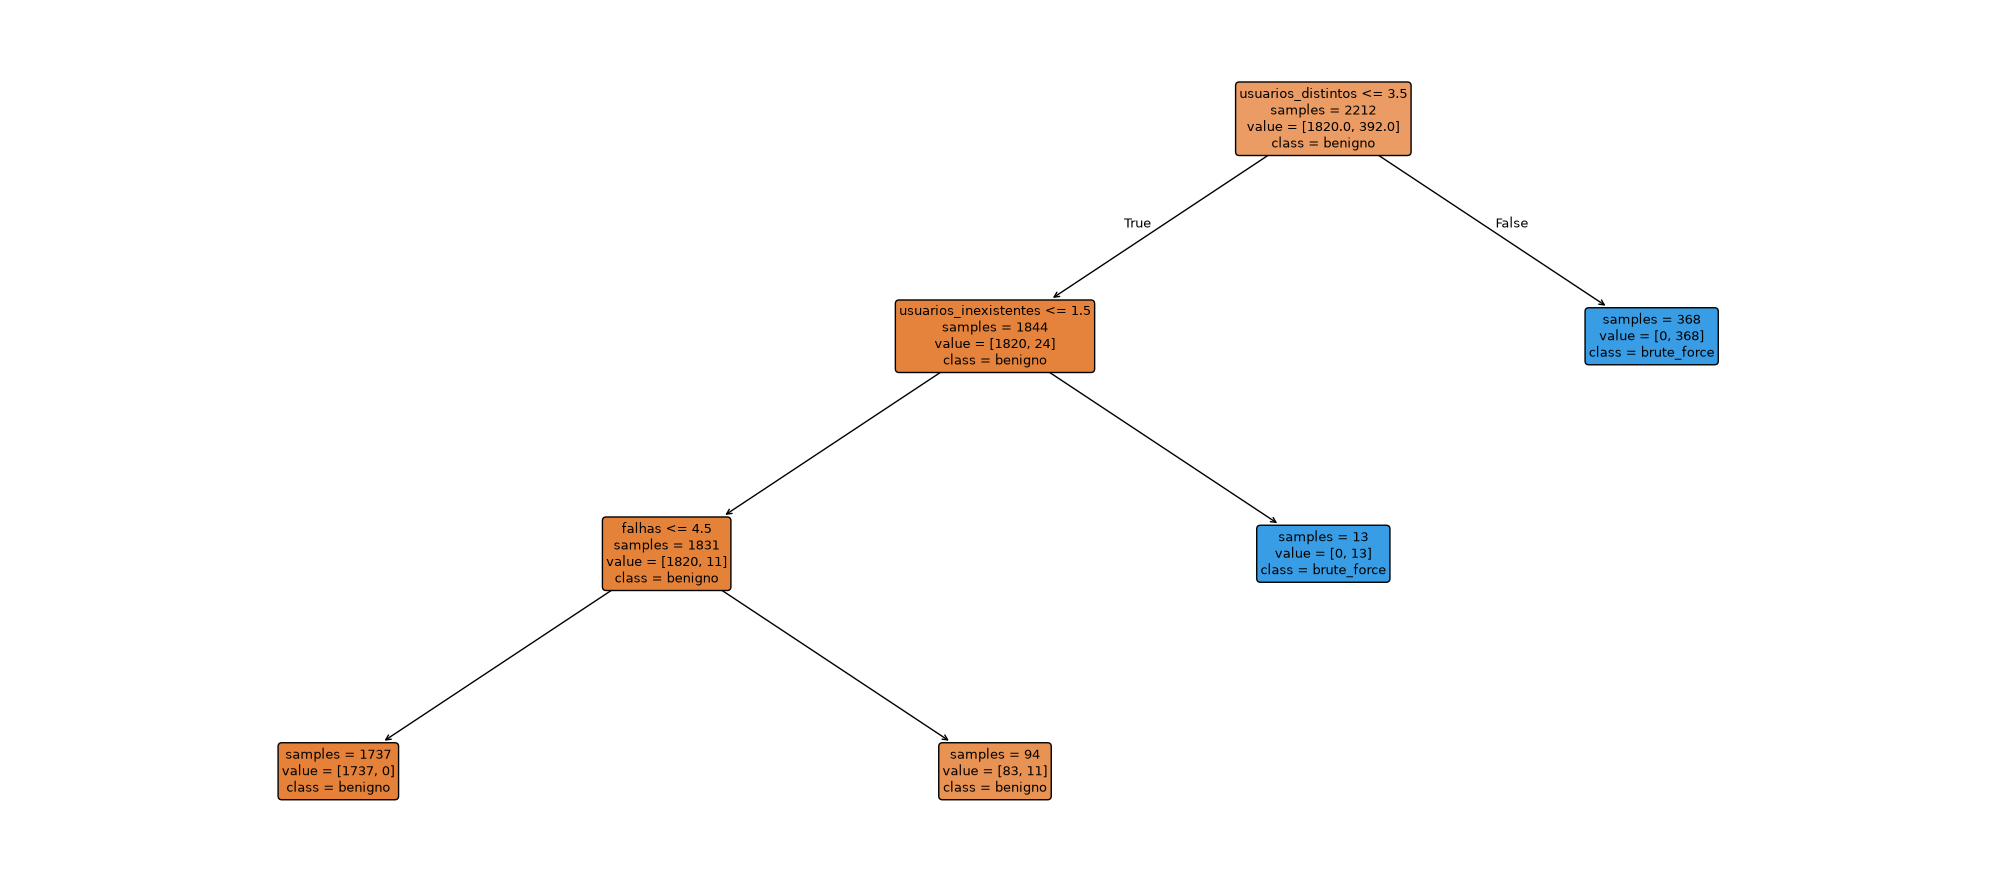

In [15]:
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    arvore, feature_names=list(X.columns), class_names=["benigno", "brute_force"],
    filled=True, rounded=True, impurity=False, proportion=False, fontsize=9, ax=ax
)
plt.tight_layout()
plt.show()

### **c.5** — Quais features a árvore escolheu

In [16]:
# Lê a estrutura da árvore direto do objeto treinado, em vez de olhar o gráfico.
t = arvore.tree_
nomes = list(X.columns)

def no(i, nivel, lado=""):
    if t.feature[i] == -2:
        n = int(t.n_node_samples[i]); v = t.value[i][0]
        print(f"{'  '*nivel}{lado}folha: n={n}, classe={'brute_force' if v[1] > v[0] else 'benigno'}")
        return
    print(f"{'  '*nivel}{lado}[{nomes[t.feature[i]]} <= {t.threshold[i]:.3f}]  n={int(t.n_node_samples[i])}")
    if nivel < 2:
        no(t.children_left[i], nivel + 1, "SIM  ")
        no(t.children_right[i], nivel + 1, "NÃO  ")

no(0, 0)

print("\nImportâncias (ganho total por feature):")
print(pd.Series(arvore.feature_importances_, index=nomes)
        .sort_values(ascending=False).round(4).to_string())

[usuarios_distintos <= 3.500]  n=2212
  SIM  [usuarios_inexistentes <= 1.500]  n=1844
    SIM  [falhas <= 4.500]  n=1831
    NÃO  folha: n=13, classe=brute_force
  NÃO  folha: n=368, classe=brute_force

Importâncias (ganho total por feature):
usuarios_distintos       0.9553
usuarios_inexistentes    0.0408
falhas                   0.0039
tentativas_total         0.0000
intervalo_medio_seg      0.0000
fracao_noturna           0.0000
sucesso_apos_falhas      0.0000
portas_distintas         0.0000


Nível 1: `usuarios_distintos` (limiar 3,5). Nível 2: `usuarios_inexistentes`
(limiar 1,5) — o ramo `usuarios_distintos > 3,5` já é folha pura com n=368.

A árvore **não reinventou a regra**: trocou a feature principal. `usuarios_distintos`
responde sozinha por **95,5 %** do ganho; `usuarios_inexistentes` por 4,1 % e
`falhas` — âncora da regra manual — por apenas 0,4 %, e ainda assim no 3º nível e
com limiar 4,5, não 10. As outras cinco features têm ganho zero.

É o sinal apontado na autópsia do item b): os 111 FN tinham `usuarios_distintos`
mediano 5, acima do corte encontrado pela árvore. A regra media volume de falhas
onde o discriminante real é a dispersão de credenciais tentadas.

| Modelo (teste, n=948) | Acurácia | FN | FP | Recall ataque |
|---|---|---|---|---|
| Regra manual | 0,9684 | 28 | 2 | 0,8333 |
| Árvore d=3 | 0,9979 | 2 | 0 | 0,9881 |

A árvore elimina 26 dos 28 ataques não detectados e ainda zera os falsos positivos.

---
## Item d) — Regressão logística com Pipeline

### **d.1** — Pipeline: StandardScaler + LogisticRegression

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# O scaler vai DENTRO do Pipeline: assim ele é ajustado só no treino a cada fit,
# sem enxergar o teste. Ajustar o scaler na base inteira seria vazamento.
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
logreg.fit(X_tr, y_tr)

res_logreg = avaliar_modelo(logreg, X_te, y_te, "Reg. logística (com scaler)")
resultados_aquecimento.append(res_logreg)

print("n_iter_ =", logreg.named_steps["clf"].n_iter_[0])

--- Reg. logística (com scaler) ---
acurácia: 0.9905
TN=779  FP=1  FN=8  TP=160
recall(ataque)=0.9524  precisão(ataque)=0.9938
              precision    recall  f1-score   support

     benigno       0.99      1.00      0.99       780
 brute_force       0.99      0.95      0.97       168

    accuracy                           0.99       948
   macro avg       0.99      0.98      0.98       948
weighted avg       0.99      0.99      0.99       948

n_iter_ = 20


### **d.2** — Coeficientes por feature

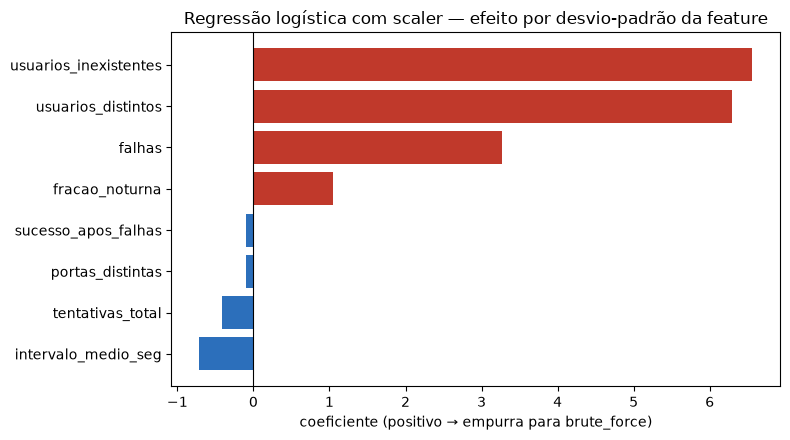

intervalo_medio_seg     -0.713
tentativas_total        -0.410
portas_distintas        -0.100
sucesso_apos_falhas     -0.092
fracao_noturna           1.045
falhas                   3.263
usuarios_distintos       6.297
usuarios_inexistentes    6.560

intercepto = 1.522


In [18]:
coefs = pd.Series(
    logreg.named_steps["clf"].coef_[0], index=list(X.columns)
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
cores = ["#c0392b" if v > 0 else "#2c6fbb" for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=cores)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("coeficiente (positivo → empurra para brute_force)")
ax.set_title("Regressão logística com scaler — efeito por desvio-padrão da feature")
plt.tight_layout()
plt.show()

print(coefs.round(3).to_string())
print(f"\nintercepto = {logreg.named_steps['clf'].intercept_[0]:.3f}")

`usuarios_inexistentes` (+6,56) e `usuarios_distintos` (+6,30) dominam, seguidos de
`falhas` (+3,26) e `fracao_noturna` (+1,05). `intervalo_medio_seg` é negativo
(−0,71): quanto mais espaçadas as tentativas, mais humano o comportamento.

`tentativas_total` sai **negativo** (−0,41), o que parece contraditório. Faz
sentido quando lido como efeito condicional: é o efeito de mais tentativas
*mantendo `falhas` constante*, ou seja, de tentativas que deram certo. Um IP com
muitas tentativas e poucas falhas é usuário legítimo. O par de coeficientes está
codificando a **razão de falhas**, não os dois volumes isoladamente.

### **d.3** — Experimento obrigatório: sem StandardScaler

In [19]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Mesmo modelo, mesmos dados, mesmo max_iter — só sem a padronização.
logreg_sem = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always", ConvergenceWarning)
    logreg_sem.fit(X_tr, y_tr)
    convergiu = not any(issubclass(a.category, ConvergenceWarning) for a in avisos)

res_logreg_sem = avaliar_modelo(logreg_sem, X_te, y_te, "Reg. logística (sem scaler)")
resultados_aquecimento.append(res_logreg_sem)

print(f"n_iter_ com scaler : {logreg.named_steps['clf'].n_iter_[0]}")
print(f"n_iter_ sem scaler : {logreg_sem.n_iter_[0]}")
print(f"convergiu sem scaler? {convergiu}")
if avisos:
    print("aviso emitido:", str(avisos[-1].message)[:120])

--- Reg. logística (sem scaler) ---
acurácia: 0.9989
TN=780  FP=0  FN=1  TP=167
recall(ataque)=0.9940  precisão(ataque)=1.0000
              precision    recall  f1-score   support

     benigno       1.00      1.00      1.00       780
 brute_force       1.00      0.99      1.00       168

    accuracy                           1.00       948
   macro avg       1.00      1.00      1.00       948
weighted avg       1.00      1.00      1.00       948

n_iter_ com scaler : 20
n_iter_ sem scaler : 635
convergiu sem scaler? True


Sem o scaler o modelo **convergiu**, mas precisou de **635 iterações contra 20** —
32× mais. E a acurácia **subiu** (0,9905 → 0,9989), resultado contraintuitivo que
o item d.5 investiga.

### **d.4** — Regra manual × árvore × regressão logística

In [20]:
# Só entram resultados medidos no MESMO conjunto de teste (948 linhas).
tabela = pd.DataFrame([r for r in resultados_aquecimento if r["nome"] != "Regra manual (falhas>=10 & usuarios_inexistentes>=1)"])
tabela["recall_ataque"] = tabela["TP"] / (tabela["TP"] + tabela["FN"])
tabela["precisao_ataque"] = tabela["TP"] / (tabela["TP"] + tabela["FP"])
tabela = tabela[["nome", "acuracia", "FN", "FP", "recall_ataque", "precisao_ataque"]].round(4)

display(tabela)
print(f"\nBaseline trivial no teste: {1 - y_te.mean():.4f}")

,nome,acuracia,FN,FP,recall_ataque,precisao_ataque
0,Regra manual (teste),0.9684,28,2,0.8333,0.9859
1,Árvore d=3,0.9979,2,0,0.9881,1.0000
2,Reg. logística (com scaler),0.9905,8,1,0.9524,0.9938
3,Reg. logística (sem scaler),0.9989,1,0,0.9940,1.0000



Baseline trivial no teste: 0.8228


Todos os modelos ficam entre 0,968 e 0,999, contra baseline trivial de 0,8228 — a
acurácia não os distingue. A diferença entre 0,9989 e 0,9979 é de **um único fluxo
em 948** e não é evidência de nada.

O que separa os modelos é o recall da classe de ataque: 0,8333 na regra manual
contra 0,9881 na árvore. Em detecção, o custo do FN não é simétrico ao do FP.

### **d.5** — Isolando as duas causas: condicionamento × regularização

A acurácia subiu sem o scaler, o que é contraintuitivo. Hipótese: o efeito não vem
da padronização em si, mas da penalidade L2 (`C=1.0`, ligada por padrão), que age
sobre os coeficientes na unidade de cada feature. Teste: repetir as quatro
combinações com `max_iter` alto o bastante para todas convergirem.

In [21]:
comparacao = []
for nome, usar_scaler, C in [
    ("com scaler,  C=1",    True,  1.0),
    ("sem scaler,  C=1",    False, 1.0),
    ("com scaler,  C=1e6",  True,  1e6),
    ("sem scaler,  C=1e6",  False, 1e6),
]:
    if usar_scaler:
        m = Pipeline([("scaler", StandardScaler()),
                      ("clf", LogisticRegression(max_iter=200000, C=C, random_state=RANDOM_STATE))])
        m.fit(X_tr, y_tr)
        clf = m.named_steps["clf"]
        coef_dp = clf.coef_[0]                              # já está por desvio-padrão
    else:
        m = clf = LogisticRegression(max_iter=200000, C=C, random_state=RANDOM_STATE)
        m.fit(X_tr, y_tr)
        coef_dp = clf.coef_[0] * X_tr.std(ddof=0).values    # converte para a mesma unidade

    comparacao.append({
        "config": nome,
        "acuracia": round(accuracy_score(y_te, m.predict(X_te)), 4),
        "n_iter_": int(clf.n_iter_[0]),
        "norma_coef_por_dp": round(float(np.linalg.norm(coef_dp)), 2),
    })

display(pd.DataFrame(comparacao))

,config,acuracia,n_iter_,norma_coef_por_dp
0,"com scaler, C=1",0.9905,20,9.75
1,"sem scaler, C=1",0.9989,635,57.18
2,"com scaler, C=1e6",0.9979,28,64.42
3,"sem scaler, C=1e6",0.9979,254,115.70


As duas causas se separam:

**Regularização (explica a acurácia).** Com `C=1e6`, com e sem scaler dão a mesma
acurácia — 0,9979. A diferença do d.3 não vinha da escala. A penalidade L2 age
sobre o coeficiente na unidade da feature: `usuarios_distintos` tem desvio-padrão
8,997, então sem padronizar basta um coeficiente de ≈0,70 para o mesmo efeito, e
0,70² é irrisório perto de 6,30². A norma comprova: mesmo `C=1`, a norma passa de
**9,75 (com scaler) para 57,18 (sem)** — valor próximo dos 64,42 que a versão
padronizada só alcança com a regularização desligada. Sem scaler, `C=1` é
praticamente "sem regularização" para as features de maior variância.

**Condicionamento (explica as iterações).** O custo em iterações persiste nos dois
regimes: 20→635 com `C=1`, 28→254 com `C=1e6`. Esse é o efeito puro da amplitude
de ~16.000× registrada no item b.3.

Conclusão: nesta base o scaler não melhora acurácia — mas torna a otimização bem
condicionada e a penalidade comparável entre features. Com o `max_iter=100` padrão
do scikit-learn, a versão sem scaler nem teria convergido.